# ВЭС — лучший pipeline: safe_features + cluster_axis

Этот ноутбук фиксирует лучший найденный research-вариант:

```text
safe_features + cluster_axis
```

Твой результат:

```text
7.468638473929988
```

Обычный baseline здесь не обучается.  
`safe_features` используется только как контрольная точка в локальной проверке.

Нужные входные файлы:

```text
data/merged_dataset.csv
data/merged_valid_dataset.csv
data/azov_turbines_from_map.csv
```

или вместо merged:

```text
data/train_dataset.csv
data/valid_features.csv
data/azov_turbines_from_map.csv
```

Главный submission после запуска:

```text
outputs/pipeline_746/submission_best_safe_cluster_axis_746.csv
```

Главный отчёт:

```text
outputs/pipeline_746/best_cluster_axis_vs_safe_746_report.csv
```


In [1]:
# -*- coding: utf-8 -*-

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.interpolate import PchipInterpolator
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

INSTALLED_CAPACITY_MW = 90.09
TURBINES_TOTAL = 26
CUT_IN_SPEED = 3.0
RATED_SPEED = 12.0
CUT_OUT_SPEED = 25.0
AIR_DENSITY_REF = 1.225
EPS = 1e-6

NWP_SHIFTS = [-6, -3, -2, -1, 1, 2, 3, 6]

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs") / "pipeline_746"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CANDIDATES = [
    DATA_DIR / "merged_dataset.csv",
    DATA_DIR / "train_dataset.csv",
]

VALID_CANDIDATES = [
    DATA_DIR / "merged_valid_dataset.csv",
    DATA_DIR / "valid_features.csv",
]

TRAIN_PATH = next((p for p in TRAIN_CANDIDATES if p.exists()), TRAIN_CANDIDATES[0])
VALID_PATH = next((p for p in VALID_CANDIDATES if p.exists()), VALID_CANDIDATES[0])

SAFE_SUBMISSION_PATH = OUTPUT_DIR / "submission_safe_features_exact_746.csv"
SAFE_LOCAL_CHECK_PATH = OUTPUT_DIR / "exact_746_local_check.csv"

BLEND_WEIGHTS = {
    "cat_mae_direct": 0.361831,
    "hgb_q545": 0.235409,
    "xgb_residual": 0.177644,
    "hgb_q570": 0.116581,
    "lgb_residual": 0.064663,
    "hgb_q530": 0.043873,
}

print("TRAIN_PATH:", TRAIN_PATH)
print("VALID_PATH:", VALID_PATH)

TRAIN_PATH: data\merged_dataset.csv
VALID_PATH: data\merged_valid_dataset.csv


## 1. Загрузка данных

In [2]:
print("1. Загрузка данных...")

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Не найден train-файл: {TRAIN_PATH}")

if not VALID_PATH.exists():
    raise FileNotFoundError(f"Не найден valid-файл: {VALID_PATH}")

train_raw = pd.read_csv(TRAIN_PATH)
valid_raw = pd.read_csv(VALID_PATH)

print("train_raw:", train_raw.shape)
print("valid_raw:", valid_raw.shape)

TARGET_CANDIDATES = [
    "Выработка. Результирующий расчет",
    "target",
    "Выработка",
]

DATETIME_CANDIDATES = [
    "METEOFORECASTHOUR_OPENM_Datetime",
    "Datetime",
    "datetime",
    "date",
    "time",
]

REPAIR_CANDIDATES = [
    "Кол-во_ВЭУ_в_ремонте",
    "turbines_in_repair",
    "repair",
]

target_col = None
for c in TARGET_CANDIDATES:
    if c in train_raw.columns and c not in valid_raw.columns:
        target_col = c
        break

if target_col is None:
    diff_cols = [c for c in train_raw.columns if c not in valid_raw.columns]
    if len(diff_cols) == 0:
        raise ValueError("Не найден target.")
    target_col = diff_cols[0]

datetime_col = None
for c in DATETIME_CANDIDATES:
    if c in train_raw.columns and c in valid_raw.columns:
        datetime_col = c
        break

if datetime_col is None:
    raise ValueError("Не найдена datetime-колонка.")

repair_col = None
for c in REPAIR_CANDIDATES:
    if c in train_raw.columns and c in valid_raw.columns:
        repair_col = c
        break

if repair_col is None:
    common_cols = [c for c in train_raw.columns if c in valid_raw.columns]
    repair_col = common_cols[-1]

print("target_col:", target_col)
print("datetime_col:", datetime_col)
print("repair_col:", repair_col)

train = train_raw.rename(
    columns={
        datetime_col: "datetime",
        target_col: "target",
        repair_col: "turbines_in_repair",
    }
).copy()

valid = valid_raw.rename(
    columns={
        datetime_col: "datetime",
        repair_col: "turbines_in_repair",
    }
).copy()

if not train.columns.is_unique:
    print("train duplicate columns:", train.columns[train.columns.duplicated()].tolist())
    train = train.loc[:, ~train.columns.duplicated()].copy()

if not valid.columns.is_unique:
    print("valid duplicate columns:", valid.columns[valid.columns.duplicated()].tolist())
    valid = valid.loc[:, ~valid.columns.duplicated()].copy()

train["datetime"] = pd.to_datetime(train["datetime"], errors="coerce")
valid["datetime"] = pd.to_datetime(valid["datetime"], errors="coerce")

train["row_id"] = np.arange(len(train))
valid["row_id"] = np.arange(len(valid))

train["source"] = "train"
valid["source"] = "valid"

train = train.sort_values("datetime").reset_index(drop=True)
valid = valid.sort_values("datetime").reset_index(drop=True)

print("train:", train.shape)
print("valid:", valid.shape)
display(train.head())
display(valid.head())

1. Загрузка данных...
train_raw: (32434, 36)
valid_raw: (2126, 35)
target_col: Выработка. Результирующий расчет
datetime_col: METEOFORECASTHOUR_OPENM_Datetime
repair_col: Кол-во_ВЭУ_в_ремонте
train: (32434, 38)
valid: (2126, 37)


,datetime,month,hour_of_day,target,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,...,QV2M,PS,WS10M,WD10M,WS50M,WD50M,T2MWET,WSC,row_id,source
0,2022-01-01 00:00:00,1,0,0.697,2.77,4.27,4.62,NaN,0.244,0.249,...,2.98,101.36,1.70,272.4,2.07,271.9,-2.24,2.87,32433,train
1,2022-01-01 01:00:00,1,1,4.413,2.91,4.40,4.78,NaN,0.243,0.249,...,2.99,101.32,2.10,259.0,2.59,258.6,-2.22,3.59,32432,train
2,2022-01-01 02:00:00,1,2,5.362,3.11,4.92,5.36,NaN,0.237,0.246,...,3.00,101.30,2.69,248.9,3.38,248.5,-2.23,4.68,32431,train
3,2022-01-01 03:00:00,1,3,4.879,3.02,4.66,5.14,NaN,0.236,0.247,...,3.03,101.26,3.28,240.2,4.19,240.1,-2.18,5.80,32430,train
4,2022-01-01 04:00:00,1,4,6.309,3.26,4.50,4.82,NaN,0.220,0.233,...,3.10,101.22,3.76,232.5,4.87,232.4,-2.00,6.75,32429,train


,datetime,month,hour_of_day,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,wind_direction_120m,...,QV2M,PS,WS10M,WD10M,WS50M,WD50M,T2MWET,WSC,row_id,source
0,2026-01-01 00:00:00,1,0,4.02,6.80,7.70,8.11,0.264,0.270,0.271,...,2.01,100.49,6.52,258.4,9.17,258.7,-5.90,12.70,2125,valid
1,2026-01-01 01:00:00,1,1,3.76,6.66,7.83,8.42,0.253,0.262,0.265,...,2.08,100.52,6.66,255.6,9.29,255.9,-5.67,12.87,2124,valid
2,2026-01-01 02:00:00,1,2,3.45,6.86,8.97,10.08,0.240,0.251,0.256,...,2.17,100.56,6.83,255.3,9.43,255.8,-5.29,13.06,2123,valid
3,2026-01-01 03:00:00,1,3,4.14,7.45,9.31,10.57,0.250,0.258,0.261,...,2.29,100.60,6.86,260.1,9.31,260.5,-4.96,12.90,2122,valid
4,2026-01-01 04:00:00,1,4,4.63,7.98,9.33,10.11,0.256,0.262,0.265,...,2.35,100.64,6.63,267.9,8.92,268.2,-4.97,12.36,2121,valid


## 2. Базовые признаки и safe-блоки EXACT

In [3]:
print("2. Генерация признаков...")

full = pd.concat([train, valid], ignore_index=True, sort=False)
full = full.sort_values("datetime").reset_index(drop=True)

SAFE_FEATURE_BLOCKS = {
    "shear": [],
    "cap13": [],
    "direction_sectors": [],
    "nasa_openm_disagreement": [],
    "isotonic": [],
}

# ------------------------------------------------------------
# Время
# ------------------------------------------------------------

full["month"] = full["datetime"].dt.month
full["hour_of_day"] = full["datetime"].dt.hour
full["dayofyear"] = full["datetime"].dt.dayofyear
full["dayofweek"] = full["datetime"].dt.dayofweek

full["hour_sin"] = np.sin(2 * np.pi * full["hour_of_day"] / 24)
full["hour_cos"] = np.cos(2 * np.pi * full["hour_of_day"] / 24)

full["month_sin"] = np.sin(2 * np.pi * full["month"] / 12)
full["month_cos"] = np.cos(2 * np.pi * full["month"] / 12)

full["dayofyear_sin"] = np.sin(2 * np.pi * full["dayofyear"] / 366)
full["dayofyear_cos"] = np.cos(2 * np.pi * full["dayofyear"] / 366)

# ------------------------------------------------------------
# Ветер
# ------------------------------------------------------------

speed_cols = [
    "wind_speed_10m",
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_180m",
]

direction_cols = [
    "wind_direction_10m",
    "wind_direction_80m",
    "wind_direction_120m",
    "wind_direction_180m",
]

speed_cols = [c for c in speed_cols if c in full.columns]
direction_cols = [c for c in direction_cols if c in full.columns]

for col in speed_cols:
    full[f"{col}_sq"] = full[col] ** 2
    full[f"{col}_cube"] = full[col] ** 3

for col in direction_cols:
    suffix = col.replace("wind_direction_", "")
    angle = np.deg2rad(full[col] * 1000)

    full[f"wind_dir_{suffix}_sin"] = np.sin(angle)
    full[f"wind_dir_{suffix}_cos"] = np.cos(angle)

if "wind_speed_120m" in full.columns:
    full["ws_120_cube"] = full["wind_speed_120m"] ** 3

if {"wind_speed_120m", "wind_speed_80m"}.issubset(full.columns):
    full["ws_diff_120_80"] = full["wind_speed_120m"] - full["wind_speed_80m"]
    full["ws_ratio_120_80"] = full["wind_speed_120m"] / (full["wind_speed_80m"] + EPS)

if {"wind_speed_180m", "wind_speed_120m"}.issubset(full.columns):
    full["ws_diff_180_120"] = full["wind_speed_180m"] - full["wind_speed_120m"]

if {"wind_gusts_10m", "wind_speed_10m"}.issubset(full.columns):
    full["gust_ratio_10m"] = full["wind_gusts_10m"] / (full["wind_speed_10m"] + EPS)

# ------------------------------------------------------------
# Физика
# ------------------------------------------------------------

temperature_mean = 0.5 * (full["temperature_80m"] + full["temperature_120m"])

full["air_density"] = (
    full["pressure_msl"] * 100
) / (287.05 * (temperature_mean + 273.15))

full["density_ratio"] = (
    full["air_density"] / AIR_DENSITY_REF
).clip(0.75, 1.30)

for height in [80, 120]:
    speed_col = f"wind_speed_{height}m"

    if speed_col in full.columns:
        full[f"wind_speed_{height}m_density_corrected"] = (
            full[speed_col] * (full["density_ratio"] ** (1 / 3))
        )

        full[f"wind_power_density_{height}m"] = (
            0.5 * full["air_density"] * full[speed_col] ** 3
        )

availability = (
    (TURBINES_TOTAL - full["turbines_in_repair"])
    .clip(0, TURBINES_TOTAL)
    / TURBINES_TOTAL
)

full["available_capacity_mw"] = availability * INSTALLED_CAPACITY_MW

# ------------------------------------------------------------
# p_theory
# ------------------------------------------------------------

for height in [80, 120]:
    speed_col = f"wind_speed_{height}m"

    if speed_col in full.columns:
        speed = full[speed_col].clip(lower=0)

        curve = (
            (speed ** 3 - CUT_IN_SPEED ** 3)
            / (RATED_SPEED ** 3 - CUT_IN_SPEED ** 3)
        ).clip(0, 1)

        curve = curve.where(speed >= CUT_IN_SPEED, 0)
        curve = curve.where(speed < CUT_OUT_SPEED, 0)

        full[f"p_theory_{height}"] = (
            INSTALLED_CAPACITY_MW * curve * availability
        )

if {"p_theory_80", "p_theory_120"}.issubset(full.columns):
    full["p_theory_mean_80_120"] = (
        0.5 * (full["p_theory_80"] + full["p_theory_120"])
    )

# ------------------------------------------------------------
# EXACT safe block 1: shear
# ------------------------------------------------------------

def add_shear_feature(df, low_h, high_h):
    low_col = f"wind_speed_{low_h}m"
    high_col = f"wind_speed_{high_h}m"
    out_col = f"shear_{low_h}_{high_h}"

    if low_col in df.columns and high_col in df.columns:
        df[out_col] = (
            np.log((df[high_col].clip(lower=EPS)) / (df[low_col].clip(lower=EPS)))
            / np.log(high_h / low_h)
        )
        df[out_col] = df[out_col].replace([np.inf, -np.inf], np.nan)
        SAFE_FEATURE_BLOCKS["shear"].append(out_col)

for low_h, high_h in [(10, 80), (80, 120), (120, 180), (80, 180), (10, 120)]:
    add_shear_feature(full, low_h, high_h)

# ------------------------------------------------------------
# EXACT safe block 2: cap13
# ------------------------------------------------------------

if "wind_speed_120m" in full.columns:
    cap = 13
    base = f"wind120_cap{cap}"

    full[f"{base}_clipped"] = full["wind_speed_120m"].clip(upper=cap)
    full[f"{base}_above"] = (full["wind_speed_120m"] - cap).clip(lower=0)
    full[f"{base}_is_above"] = (full["wind_speed_120m"] > cap).astype(int)
    full[f"{base}_clipped_cube"] = full[f"{base}_clipped"] ** 3

    SAFE_FEATURE_BLOCKS["cap13"] += [
        f"{base}_clipped",
        f"{base}_above",
        f"{base}_is_above",
        f"{base}_clipped_cube",
    ]

# ------------------------------------------------------------
# EXACT safe block 3: direction sectors
# оставляем с NaN-fix, но без изменения самой идеи
# ------------------------------------------------------------

for h in [80, 120, 180]:
    col = f"wind_direction_{h}m"

    if col in full.columns:
        deg = (full[col] * 1000) % 360

        for n_sec in [8, 16]:
            sec_col = f"wind_dir_{h}m_sector_{n_sec}"

            sector = np.floor(deg / (360 / n_sec))
            sector = (
                sector
                .replace([np.inf, -np.inf], np.nan)
                .fillna(-1)
                .clip(-1, n_sec - 1)
                .astype(int)
            )

            full[sec_col] = sector
            SAFE_FEATURE_BLOCKS["direction_sectors"].append(sec_col)

# ------------------------------------------------------------
# EXACT safe block 4: NASA/OpenM disagreement
# ВАЖНО: только тот набор, который был в 7.48-ноутбуке:
# ws10, ws80, pressure, temp80, wd10
# Без ws120/temp120/wd80.
# ------------------------------------------------------------

def add_diff_if_possible(openm_col, nasa_col, new_col):
    if openm_col in full.columns and nasa_col in full.columns:
        full[new_col] = full[openm_col] - full[nasa_col]
        full[new_col] = full[new_col].replace([np.inf, -np.inf], np.nan)
        SAFE_FEATURE_BLOCKS["nasa_openm_disagreement"].append(new_col)

add_diff_if_possible("wind_speed_10m", "WS10M", "ws10_openm_minus_nasa")
add_diff_if_possible("wind_speed_80m", "WS50M", "ws80_openm_minus_nasa50")
add_diff_if_possible("pressure_msl", "PS", "pressure_msl_minus_ps")
add_diff_if_possible("temperature_80m", "T2M", "temp80_minus_t2m")

if "wind_direction_10m" in full.columns and "WD10M" in full.columns:
    openm_deg = (full["wind_direction_10m"] * 1000) % 360
    nasa_deg = full["WD10M"] % 360

    diff = ((openm_deg - nasa_deg + 180) % 360) - 180
    diff = diff.replace([np.inf, -np.inf], np.nan)

    full["wd10_openm_minus_nasa_circular"] = diff
    SAFE_FEATURE_BLOCKS["nasa_openm_disagreement"].append("wd10_openm_minus_nasa_circular")

for block_name in SAFE_FEATURE_BLOCKS:
    SAFE_FEATURE_BLOCKS[block_name] = sorted(list(dict.fromkeys(SAFE_FEATURE_BLOCKS[block_name])))

print("full:", full.shape)
for block_name, cols in SAFE_FEATURE_BLOCKS.items():
    print(block_name, len(cols), cols)

2. Генерация признаков...
full: (34560, 97)
shear 5 ['shear_10_120', 'shear_10_80', 'shear_120_180', 'shear_80_120', 'shear_80_180']
cap13 4 ['wind120_cap13_above', 'wind120_cap13_clipped', 'wind120_cap13_clipped_cube', 'wind120_cap13_is_above']
direction_sectors 6 ['wind_dir_120m_sector_16', 'wind_dir_120m_sector_8', 'wind_dir_180m_sector_16', 'wind_dir_180m_sector_8', 'wind_dir_80m_sector_16', 'wind_dir_80m_sector_8']
nasa_openm_disagreement 5 ['pressure_msl_minus_ps', 'temp80_minus_t2m', 'wd10_openm_minus_nasa_circular', 'ws10_openm_minus_nasa', 'ws80_openm_minus_nasa50']
isotonic 0 []


## 3. EMA и NWP-соседи

In [4]:
print("3. EMA и NWP-соседи...")

full = full.sort_values("datetime").reset_index(drop=True)
time_indexed = full.set_index("datetime")

ewm_spans = {
    "3h": 3,
    "5h": 5,
    "7h": 7,
}

ema_cols = [
    "wind_speed_120m_cube",
    "p_theory_80",
    "p_theory_120",
    "wind_power_density_120m",
]

ema_cols = [c for c in ema_cols if c in full.columns]

for col in ema_cols:
    for window_str, span_val in ewm_spans.items():
        full[f"{col}_smooth_{window_str}"] = (
            time_indexed[col]
            .ewm(span=span_val, min_periods=1)
            .mean()
            .reindex(full["datetime"])
            .to_numpy()
        )

    full[f"{col}_minus_smooth_3h"] = full[col] - full[f"{col}_smooth_3h"]

nwp_base_cols = [
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_120m_cube",
    "wind_speed_120m_density_corrected",
    "p_theory_120",
    "wind_power_density_120m",
]

nwp_base_cols = [c for c in nwp_base_cols if c in full.columns]

for col in nwp_base_cols:
    for shift_hours in NWP_SHIFTS:
        shifted_datetime = full["datetime"] + pd.to_timedelta(shift_hours, unit="h")
        label = f"plus_{shift_hours}h" if shift_hours > 0 else f"minus_{abs(shift_hours)}h"

        full[f"{col}_nwp_{label}"] = (
            time_indexed[col]
            .reindex(shifted_datetime)
            .to_numpy()
        )

print("full:", full.shape)

3. EMA и NWP-соседи...
full: (34560, 161)


## 4. p_empirical: PCHIP + isotonic

In [5]:
print("4. Эмпирическая кривая мощности...")

train_base = (
    full[full["source"].eq("train")]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

valid_base = (
    full[full["source"].eq("valid")]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

def add_empirical_power_features(frame, reference):
    frame = frame.copy()
    reference = reference.copy()

    ref_available = reference["available_capacity_mw"].clip(lower=1.0)
    reference["cf_available"] = (
        reference["target"] / ref_available
    ).clip(0, 1.15)

    iso_cols = []

    for height in [80, 120]:
        speed_col = f"wind_speed_{height}m_density_corrected"

        if speed_col not in frame.columns or speed_col not in reference.columns:
            continue

        bins = np.arange(0, 26.5, 0.5)

        ref = reference[[speed_col, "cf_available"]].dropna().copy()
        ref["bin_id"] = pd.cut(ref[speed_col], bins=bins, labels=False)

        curve = (
            ref.groupby("bin_id", as_index=False)
            .agg(
                cf=("cf_available", "median"),
                n=("cf_available", "size"),
            )
        )

        curve = curve[curve["n"] >= 20].copy()
        curve["speed"] = bins[curve["bin_id"].astype(int)] + 0.25
        curve = curve.sort_values("speed")

        if len(curve) == 0:
            frame[f"p_empirical_{height}"] = 0.0
            frame[f"cf_empirical_{height}"] = 0.0
            frame[f"p_empirical_iso_{height}"] = 0.0
            frame[f"cf_empirical_iso_{height}"] = 0.0

            iso_cols += [f"p_empirical_iso_{height}", f"cf_empirical_iso_{height}"]
            continue

        cf_monotonic = np.maximum.accumulate(curve["cf"].to_numpy())

        # PCHIP baseline
        x = np.r_[0.0, curve["speed"].to_numpy(), CUT_OUT_SPEED]
        y = np.r_[0.0, cf_monotonic, cf_monotonic[-1]]

        unique_x, unique_idx = np.unique(x, return_index=True)
        unique_y = y[unique_idx]

        interpolator = PchipInterpolator(unique_x, unique_y, extrapolate=True)

        speed_eval = frame[speed_col].clip(0, CUT_OUT_SPEED)

        empirical_cf = np.clip(interpolator(speed_eval), 0, 1.15)
        empirical_cf = np.where(frame[speed_col] < CUT_IN_SPEED, 0, empirical_cf)
        empirical_cf = np.where(frame[speed_col] >= CUT_OUT_SPEED, 0, empirical_cf)

        frame[f"p_empirical_{height}"] = empirical_cf * frame["available_capacity_mw"]
        frame[f"cf_empirical_{height}"] = empirical_cf

        # Isotonic exact block
        iso = IsotonicRegression(
            y_min=0.0,
            y_max=1.15,
            increasing=True,
            out_of_bounds="clip",
        )

        iso.fit(curve["speed"].to_numpy(), curve["cf"].to_numpy())

        empirical_cf_iso = np.clip(iso.predict(speed_eval), 0, 1.15)
        empirical_cf_iso = np.where(frame[speed_col] < CUT_IN_SPEED, 0, empirical_cf_iso)
        empirical_cf_iso = np.where(frame[speed_col] >= CUT_OUT_SPEED, 0, empirical_cf_iso)

        frame[f"p_empirical_iso_{height}"] = empirical_cf_iso * frame["available_capacity_mw"]
        frame[f"cf_empirical_iso_{height}"] = empirical_cf_iso

        iso_cols += [f"p_empirical_iso_{height}", f"cf_empirical_iso_{height}"]

    if {"p_empirical_80", "p_empirical_120"}.issubset(frame.columns):
        frame["p_empirical_mean_80_120"] = (
            0.5 * (frame["p_empirical_80"] + frame["p_empirical_120"])
        )

    if {"p_empirical_iso_80", "p_empirical_iso_120"}.issubset(frame.columns):
        frame["p_empirical_iso_mean_80_120"] = (
            0.5 * (frame["p_empirical_iso_80"] + frame["p_empirical_iso_120"])
        )

        iso_cols.append("p_empirical_iso_mean_80_120")

    if {"p_empirical_120", "p_theory_120"}.issubset(frame.columns):
        frame["p_empirical_minus_theory_120"] = (
            frame["p_empirical_120"] - frame["p_theory_120"]
        )

    return frame, sorted(list(dict.fromkeys(iso_cols)))

train_fe, iso_train_cols = add_empirical_power_features(train_base, train_base)
valid_fe, iso_valid_cols = add_empirical_power_features(valid_base, train_base)

SAFE_FEATURE_BLOCKS["isotonic"] = sorted(
    list(set(iso_train_cols).intersection(set(iso_valid_cols)))
)

print("train_fe:", train_fe.shape)
print("valid_fe:", valid_fe.shape)
print("isotonic:", SAFE_FEATURE_BLOCKS["isotonic"])

4. Эмпирическая кривая мощности...
train_fe: (32434, 172)
valid_fe: (2126, 172)
isotonic: ['cf_empirical_iso_120', 'cf_empirical_iso_80', 'p_empirical_iso_120', 'p_empirical_iso_80', 'p_empirical_iso_mean_80_120']


## 5. Выбор признаков EXACT

In [6]:
raw_cols = [
    "month",
    "hour_of_day",
    "wind_speed_10m",
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_180m",
    "wind_direction_10m",
    "wind_direction_80m",
    "wind_direction_120m",
    "wind_direction_180m",
    "wind_gusts_10m",
    "temperature_80m",
    "temperature_120m",
    "pressure_msl",
    "rain",
    "showers",
    "snowfall",
    "cloud_cover_low",
    "turbines_in_repair",
]

physics_cols = [
    "available_capacity_mw",
    "air_density",
    "density_ratio",
    "wind_power_density_80m",
    "wind_power_density_120m",
    "p_theory_80",
    "p_theory_120",
    "p_theory_mean_80_120",
    "p_empirical_80",
    "p_empirical_120",
    "p_empirical_mean_80_120",
    "p_empirical_minus_theory_120",
    "cf_empirical_80",
    "cf_empirical_120",
]

auto_cols = [
    col for col in train_fe.columns
    if (
        col.endswith("_sq")
        or col.endswith("_cube")
        or col.startswith("wind_dir_")
        or "_smooth_" in col
        or col.endswith("_minus_smooth_3h")
        or "_nwp_" in col
        or col.endswith("_density_corrected")
        or col.startswith("ws_")
        or col.startswith("gust_ratio")
        or col.startswith("dayofyear_")
    )
]

feature_candidates = raw_cols + physics_cols + auto_cols

baseline_features = list(dict.fromkeys([
    c for c in feature_candidates
    if c in train_fe.columns and c in valid_fe.columns
]))

safe_extra_cols = []

# EXACT order from best_ideas
for block_name in [
    "shear",
    "cap13",
    "direction_sectors",
    "nasa_openm_disagreement",
    "isotonic",
]:
    safe_extra_cols += SAFE_FEATURE_BLOCKS.get(block_name, [])

safe_extra_cols = list(dict.fromkeys([
    c for c in safe_extra_cols
    if c in train_fe.columns and c in valid_fe.columns
]))

safe_features = list(dict.fromkeys([
    c for c in baseline_features + safe_extra_cols
    if c in train_fe.columns and c in valid_fe.columns
]))

print("baseline_features:", len(baseline_features))
print("safe_extra_cols:", len(safe_extra_cols))
print("safe_features:", len(safe_features))

print("\nSafe blocks:")
for block_name, cols in SAFE_FEATURE_BLOCKS.items():
    cols2 = [c for c in cols if c in train_fe.columns and c in valid_fe.columns]
    print(block_name, len(cols2), cols2)

print("\nsafe_extra_cols EXACT:")
print(safe_extra_cols)

baseline_features: 129
safe_extra_cols: 25
safe_features: 147

Safe blocks:
shear 5 ['shear_10_120', 'shear_10_80', 'shear_120_180', 'shear_80_120', 'shear_80_180']
cap13 4 ['wind120_cap13_above', 'wind120_cap13_clipped', 'wind120_cap13_clipped_cube', 'wind120_cap13_is_above']
direction_sectors 6 ['wind_dir_120m_sector_16', 'wind_dir_120m_sector_8', 'wind_dir_180m_sector_16', 'wind_dir_180m_sector_8', 'wind_dir_80m_sector_16', 'wind_dir_80m_sector_8']
nasa_openm_disagreement 5 ['pressure_msl_minus_ps', 'temp80_minus_t2m', 'wd10_openm_minus_nasa_circular', 'ws10_openm_minus_nasa', 'ws80_openm_minus_nasa50']
isotonic 5 ['cf_empirical_iso_120', 'cf_empirical_iso_80', 'p_empirical_iso_120', 'p_empirical_iso_80', 'p_empirical_iso_mean_80_120']

safe_extra_cols EXACT:
['shear_10_120', 'shear_10_80', 'shear_120_180', 'shear_80_120', 'shear_80_180', 'wind120_cap13_above', 'wind120_cap13_clipped', 'wind120_cap13_clipped_cube', 'wind120_cap13_is_above', 'wind_dir_120m_sector_16', 'wind_dir_120m_

## 6. Функции ансамбля

In [7]:
def fit_ensemble(local_train, feature_cols, label="ensemble", fast_mode=False):
    print(f"\nОбучение ансамбля: {label}")
    print("n_features:", len(feature_cols))

    models = {}

    y_direct = local_train["target"].clip(0, INSTALLED_CAPACITY_MW)
    y_residual = local_train["target"] - local_train["p_empirical_mean_80_120"]
    y_scaled = (local_train["target"] / INSTALLED_CAPACITY_MW).clip(0, 1)

    if fast_mode:
        cat_iter = 500
        xgb_estimators = 450
        lgb_estimators = 450
        hgb_iter = 350
    else:
        cat_iter = 1200
        xgb_estimators = 900
        lgb_estimators = 900
        hgb_iter = 650

    cat = CatBoostRegressor(
        iterations=cat_iter,
        learning_rate=0.03,
        depth=6,
        loss_function="MAE",
        random_seed=RANDOM_STATE,
        verbose=0,
    )

    cat.fit(local_train[feature_cols], y_direct)
    models["cat_mae_direct"] = cat

    xgb = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=xgb_estimators,
        learning_rate=0.025,
        max_depth=5,
        min_child_weight=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        tree_method="hist",
        random_state=RANDOM_STATE,
    )

    xgb.fit(local_train[feature_cols], y_residual)
    models["xgb_residual"] = xgb

    lgbm = lgb.LGBMRegressor(
        objective="regression_l1",
        n_estimators=lgb_estimators,
        learning_rate=0.025,
        num_leaves=31,
        min_child_samples=35,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbosity=-1,
    )

    lgbm.fit(local_train[feature_cols], y_residual)
    models["lgb_residual"] = lgbm

    for q in [0.545, 0.570, 0.530]:
        model_name = f"hgb_q{int(q * 1000):03d}"

        hgb = HistGradientBoostingRegressor(
            loss="quantile",
            quantile=q,
            max_iter=hgb_iter,
            learning_rate=0.04,
            max_leaf_nodes=31,
            min_samples_leaf=30,
            l2_regularization=0.02,
            early_stopping=True,
            validation_fraction=0.12,
            random_state=RANDOM_STATE,
        )

        hgb.fit(local_train[feature_cols], y_scaled)
        models[model_name] = hgb

    return models


def predict_ensemble(models, frame, feature_cols):
    preds = {}

    preds["cat_mae_direct"] = np.clip(
        models["cat_mae_direct"].predict(frame[feature_cols]),
        0,
        INSTALLED_CAPACITY_MW,
    )

    preds["xgb_residual"] = np.clip(
        frame["p_empirical_mean_80_120"].to_numpy()
        + models["xgb_residual"].predict(frame[feature_cols]),
        0,
        INSTALLED_CAPACITY_MW,
    )

    preds["lgb_residual"] = np.clip(
        frame["p_empirical_mean_80_120"].to_numpy()
        + models["lgb_residual"].predict(frame[feature_cols]),
        0,
        INSTALLED_CAPACITY_MW,
    )

    for q in [0.545, 0.570, 0.530]:
        model_name = f"hgb_q{int(q * 1000):03d}"

        preds[model_name] = (
            np.clip(models[model_name].predict(frame[feature_cols]), 0, 1)
            * INSTALLED_CAPACITY_MW
        )

    final = np.zeros(len(frame))

    for model_name, weight in BLEND_WEIGHTS.items():
        final += preds[model_name] * weight

    final = np.clip(final, 0, INSTALLED_CAPACITY_MW)

    return final, preds

## Research: cluster-layout feature blocks vs safe_features


RESEARCH CLUSTER / LAYOUT FEATURES VS SAFE_FEATURES
Турбин: 26
Среднее ближайшее расстояние: 323.2 м
Медианное ближайшее расстояние: 328.7 м
Главная ось ВЭС: 3.99° / 183.99°
PCA explained variance: [0.86450917 0.13549083]


,cluster_id,cluster_axis_compass_deg,cluster_axis_evr,n
0,0,113.569634,0.659132,6
1,1,91.994110,0.708788,8
2,2,0.848583,0.999876,6
3,3,80.592090,0.640877,6


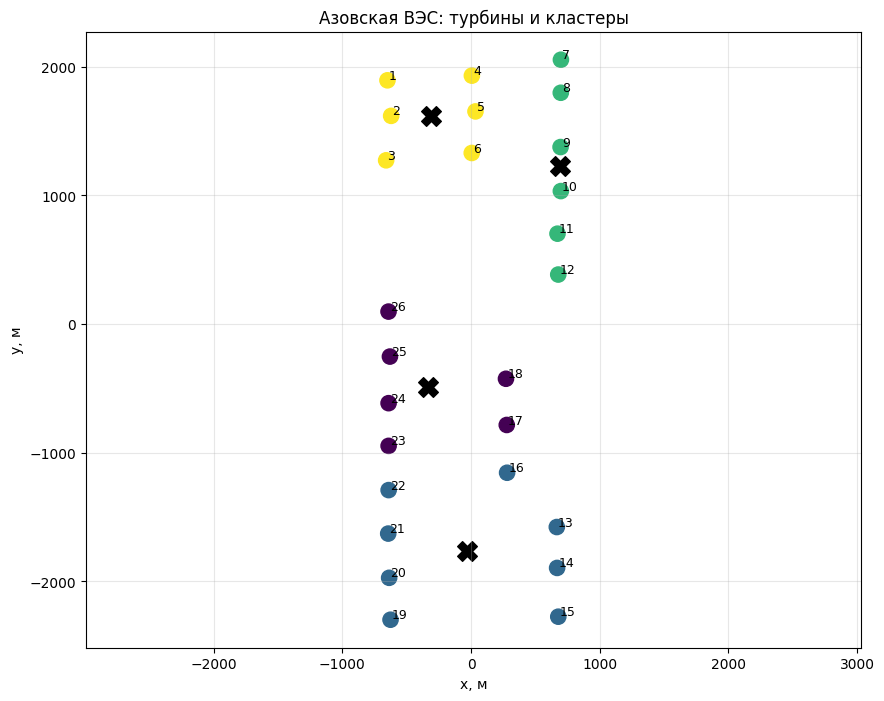

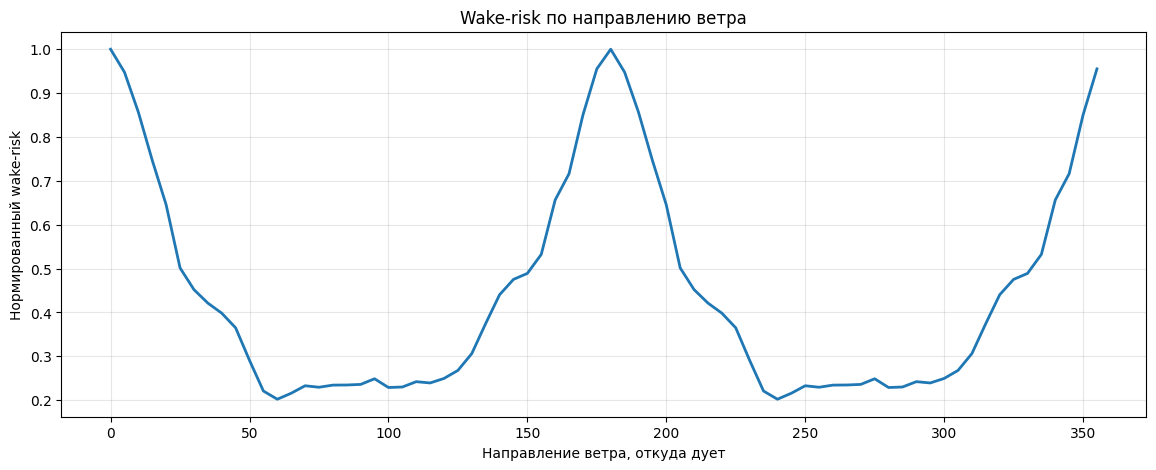


Research configs:
cluster_axis added: 11 total features: 158
['cluster0_axis_alignment', 'cluster0_axis_crosswind', 'cluster1_axis_alignment', 'cluster1_axis_crosswind', 'cluster2_axis_alignment', 'cluster2_axis_crosswind', 'cluster3_axis_alignment', 'cluster3_axis_crosswind', 'cluster_axis_alignment_mean', 'cluster_axis_alignment_max', 'cluster_axis_alignment_min']


In [8]:
# ============================================================
# RESEARCH: CLUSTER / LAYOUT FEATURES VS SAFE_FEATURES
# Обычный baseline НЕ обучается.
# ============================================================

from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform

print("=" * 90)
print("RESEARCH CLUSTER / LAYOUT FEATURES VS SAFE_FEATURES")
print("=" * 90)

TURBINE_COORDS_PATH = Path("data/azov_turbines_from_map.csv")
RESEARCH_REPORT_PATH = OUTPUT_DIR / "best_cluster_axis_vs_safe_746_report.csv"

RESEARCH_SUBMISSION_PATHS = {
    "cluster_axis": OUTPUT_DIR / "submission_best_safe_cluster_axis_746.csv",
}

if not TURBINE_COORDS_PATH.exists():
    raise FileNotFoundError(
        f"Не найден {TURBINE_COORDS_PATH}. Положи azov_turbines_from_map.csv в data/"
    )

# ------------------------------------------------------------
# 1. Геометрия турбин
# ------------------------------------------------------------

turbines = pd.read_csv(TURBINE_COORDS_PATH)

if "turbine_id" not in turbines.columns:
    turbines["turbine_id"] = np.arange(1, len(turbines) + 1)

if not {"lat", "lon"}.issubset(turbines.columns):
    raise ValueError("В файле турбин должны быть колонки lat и lon")

lat0 = turbines["lat"].mean()
lon0 = turbines["lon"].mean()

meters_per_deg_lat = 111_320
meters_per_deg_lon = 111_320 * np.cos(np.deg2rad(lat0))

turbines["x_m"] = (turbines["lon"] - lon0) * meters_per_deg_lon
turbines["y_m"] = (turbines["lat"] - lat0) * meters_per_deg_lat

XY = turbines[["x_m", "y_m"]].to_numpy()

D = squareform(pdist(XY))
D_near = D + np.eye(len(D)) * 10**9
nearest_dist = D_near.min(axis=1)

print("Турбин:", len(turbines))
print(f"Среднее ближайшее расстояние: {nearest_dist.mean():.1f} м")
print(f"Медианное ближайшее расстояние: {np.median(nearest_dist):.1f} м")

N_LAYOUT_CLUSTERS = 4

kmeans_layout = KMeans(
    n_clusters=N_LAYOUT_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=30,
)

turbines["layout_cluster"] = kmeans_layout.fit_predict(XY)

cluster_centers = pd.DataFrame(
    kmeans_layout.cluster_centers_,
    columns=["x_m", "y_m"],
)
cluster_centers["cluster_id"] = np.arange(len(cluster_centers))

# PCA всего парка
pca_layout = PCA(n_components=2)
pca_layout.fit(XY)

main_axis = pca_layout.components_[0]
axis_angle_xy_deg = (np.rad2deg(np.arctan2(main_axis[1], main_axis[0])) + 360) % 360
farm_axis_compass_deg = (90 - axis_angle_xy_deg) % 360

print(f"Главная ось ВЭС: {farm_axis_compass_deg:.2f}° / {(farm_axis_compass_deg + 180) % 360:.2f}°")
print("PCA explained variance:", pca_layout.explained_variance_ratio_)

# PCA каждого кластера
cluster_axis_rows = []

for cl in sorted(turbines["layout_cluster"].unique()):
    part = turbines[turbines["layout_cluster"].eq(cl)].copy()
    XYc = part[["x_m", "y_m"]].to_numpy()

    if len(part) >= 2:
        pcac = PCA(n_components=2)
        pcac.fit(XYc)
        axis = pcac.components_[0]
        axis_xy = (np.rad2deg(np.arctan2(axis[1], axis[0])) + 360) % 360
        axis_compass = (90 - axis_xy) % 360
        evr = pcac.explained_variance_ratio_[0]
    else:
        axis_compass = np.nan
        evr = np.nan

    cluster_axis_rows.append({
        "cluster_id": cl,
        "cluster_axis_compass_deg": axis_compass,
        "cluster_axis_evr": evr,
        "n": len(part),
    })

cluster_axis_df = pd.DataFrame(cluster_axis_rows)

display(cluster_axis_df)

plt.figure(figsize=(10, 8))
plt.scatter(turbines["x_m"], turbines["y_m"], c=turbines["layout_cluster"], s=120)
plt.scatter(cluster_centers["x_m"], cluster_centers["y_m"], c="black", marker="X", s=200)

for _, r in turbines.iterrows():
    plt.text(r["x_m"] + 10, r["y_m"] + 10, str(int(r["turbine_id"])), fontsize=9)

plt.axis("equal")
plt.grid(alpha=0.3)
plt.title("Азовская ВЭС: турбины и кластеры")
plt.xlabel("x, м")
plt.ylabel("y, м")
plt.show()

turbines.to_csv(OUTPUT_DIR / "research_turbines_clusters.csv", index=False)

# ------------------------------------------------------------
# 2. Wake table по направлению
# ------------------------------------------------------------

def compute_wake_risk_for_direction(
    XY,
    wind_from_deg,
    lateral_threshold_m=260,
    max_downwind_m=2500,
    decay_downwind_m=800,
):
    flow_to_deg = (wind_from_deg + 180) % 360
    theta = np.deg2rad(flow_to_deg)

    flow_vec = np.array([np.sin(theta), np.cos(theta)])
    side_vec = np.array([np.cos(theta), -np.sin(theta)])

    pair_count = 0
    weighted_risk = 0.0

    n = len(XY)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            delta = XY[j] - XY[i]
            downwind = np.dot(delta, flow_vec)
            lateral = abs(np.dot(delta, side_vec))

            if downwind > 0 and downwind <= max_downwind_m and lateral <= lateral_threshold_m:
                pair_count += 1
                weighted_risk += (
                    np.exp(-downwind / decay_downwind_m)
                    * np.exp(-((lateral / lateral_threshold_m) ** 2))
                )

    return pair_count, weighted_risk


directions = np.arange(0, 360, 5)

wake_rows = []

for d in directions:
    pair_count, risk_score = compute_wake_risk_for_direction(XY, d)
    wake_rows.append({
        "wind_from_deg": d,
        "wake_pair_count": pair_count,
        "wake_risk_score": risk_score,
    })

wake_table = pd.DataFrame(wake_rows)

if wake_table["wake_risk_score"].max() > 0:
    wake_table["wake_risk_score_norm"] = wake_table["wake_risk_score"] / wake_table["wake_risk_score"].max()
else:
    wake_table["wake_risk_score_norm"] = 0.0

wake_table.to_csv(OUTPUT_DIR / "research_wake_table.csv", index=False)

plt.figure(figsize=(14, 5))
plt.plot(wake_table["wind_from_deg"], wake_table["wake_risk_score_norm"], linewidth=2)
plt.title("Wake-risk по направлению ветра")
plt.xlabel("Направление ветра, откуда дует")
plt.ylabel("Нормированный wake-risk")
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 3. Research feature functions
# ------------------------------------------------------------

def circular_diff_deg(a, b):
    return ((a - b + 180) % 360) - 180


def get_wind_from_deg(frame, direction_col="wind_direction_120m"):
    if direction_col not in frame.columns:
        raise ValueError(f"Нет колонки {direction_col}")
    return (frame[direction_col] * 1000) % 360


def add_layout_wake_features_research(frame):
    out = frame.copy()
    added = []

    wind_from_deg = get_wind_from_deg(out, "wind_direction_120m")
    rounded_deg = (np.round(wind_from_deg / 5) * 5) % 360

    risk_map = dict(zip(wake_table["wind_from_deg"], wake_table["wake_risk_score_norm"]))
    pair_map = dict(zip(wake_table["wind_from_deg"], wake_table["wake_pair_count"]))

    out["layout_wake_risk_120m"] = rounded_deg.map(risk_map).fillna(wake_table["wake_risk_score_norm"].median())
    out["layout_wake_pair_count_120m"] = rounded_deg.map(pair_map).fillna(wake_table["wake_pair_count"].median())

    added += [
        "layout_wake_risk_120m",
        "layout_wake_pair_count_120m",
    ]

    diff_axis = circular_diff_deg(wind_from_deg, farm_axis_compass_deg)

    out["layout_axis_alignment"] = np.cos(2 * np.deg2rad(diff_axis))
    out["layout_axis_crosswind"] = np.sin(2 * np.deg2rad(diff_axis))

    added += [
        "layout_axis_alignment",
        "layout_axis_crosswind",
    ]

    if "wind_speed_120m" in out.columns:
        out["layout_wake_x_wind120"] = out["layout_wake_risk_120m"] * out["wind_speed_120m"]
        out["layout_wake_x_wind120_cube"] = out["layout_wake_risk_120m"] * (out["wind_speed_120m"] ** 3)

        added += [
            "layout_wake_x_wind120",
            "layout_wake_x_wind120_cube",
        ]

    return out, added


def add_cluster_flow_features(frame):
    out = frame.copy()
    added = []

    wind_from_deg = get_wind_from_deg(out, "wind_direction_120m")

    centers = cluster_centers.sort_values("cluster_id").copy()
    C = centers[["x_m", "y_m"]].to_numpy()
    cluster_ids = centers["cluster_id"].to_numpy()

    upwind_ids = []
    downwind_ids = []
    flow_range_list = []
    cross_spread_list = []
    front_density_list = []

    for d in wind_from_deg:
        flow_to_deg = (d + 180) % 360
        theta = np.deg2rad(flow_to_deg)

        flow_vec = np.array([np.sin(theta), np.cos(theta)])
        side_vec = np.array([np.cos(theta), -np.sin(theta)])

        proj_flow = C @ flow_vec
        proj_side = C @ side_vec

        upwind_ids.append(cluster_ids[np.argmin(proj_flow)])
        downwind_ids.append(cluster_ids[np.argmax(proj_flow)])

        flow_range = proj_flow.max() - proj_flow.min()
        cross_spread = proj_side.max() - proj_side.min()
        front_density = len(C) / (cross_spread + 1.0)

        flow_range_list.append(flow_range)
        cross_spread_list.append(cross_spread)
        front_density_list.append(front_density)

    out["cluster_upwind_id"] = upwind_ids
    out["cluster_downwind_id"] = downwind_ids
    out["cluster_flow_range_m"] = flow_range_list
    out["cluster_crosswind_spread_m"] = cross_spread_list
    out["cluster_front_density"] = front_density_list
    out["cluster_flow_aspect_ratio"] = out["cluster_flow_range_m"] / (out["cluster_crosswind_spread_m"] + 1.0)

    added += [
        "cluster_upwind_id",
        "cluster_downwind_id",
        "cluster_flow_range_m",
        "cluster_crosswind_spread_m",
        "cluster_front_density",
        "cluster_flow_aspect_ratio",
    ]

    if "wind_speed_120m" in out.columns:
        out["cluster_flow_range_x_wind120"] = out["cluster_flow_range_m"] * out["wind_speed_120m"]
        out["cluster_front_density_x_wind120"] = out["cluster_front_density"] * out["wind_speed_120m"]

        added += [
            "cluster_flow_range_x_wind120",
            "cluster_front_density_x_wind120",
        ]

    return out, added


def add_cluster_axis_features(frame):
    out = frame.copy()
    added = []

    wind_from_deg = get_wind_from_deg(out, "wind_direction_120m")
    align_cols = []

    for _, row in cluster_axis_df.iterrows():
        cl = int(row["cluster_id"])
        axis = row["cluster_axis_compass_deg"]

        if np.isnan(axis):
            continue

        diff = circular_diff_deg(wind_from_deg, axis)

        col_align = f"cluster{cl}_axis_alignment"
        col_cross = f"cluster{cl}_axis_crosswind"

        out[col_align] = np.cos(2 * np.deg2rad(diff))
        out[col_cross] = np.sin(2 * np.deg2rad(diff))

        align_cols.append(col_align)
        added += [col_align, col_cross]

    if len(align_cols) > 0:
        out["cluster_axis_alignment_mean"] = out[align_cols].mean(axis=1)
        out["cluster_axis_alignment_max"] = out[align_cols].max(axis=1)
        out["cluster_axis_alignment_min"] = out[align_cols].min(axis=1)

        added += [
            "cluster_axis_alignment_mean",
            "cluster_axis_alignment_max",
            "cluster_axis_alignment_min",
        ]

    return out, added


def add_cluster_chain_features(frame):
    out = frame.copy()
    added = []

    wind_from_deg = get_wind_from_deg(out, "wind_direction_120m")

    centers = cluster_centers.sort_values("cluster_id").copy()
    C = centers[["x_m", "y_m"]].to_numpy()

    score_list = []
    count_list = []
    max_list = []

    lateral_threshold_m = 450
    max_downwind_m = 3500
    decay_downwind_m = 1200

    for d in wind_from_deg:
        flow_to_deg = (d + 180) % 360
        theta = np.deg2rad(flow_to_deg)

        flow_vec = np.array([np.sin(theta), np.cos(theta)])
        side_vec = np.array([np.cos(theta), -np.sin(theta)])

        score_sum = 0.0
        count = 0
        max_score = 0.0

        for i in range(len(C)):
            for j in range(len(C)):
                if i == j:
                    continue

                delta = C[j] - C[i]
                downwind = np.dot(delta, flow_vec)
                lateral = abs(np.dot(delta, side_vec))

                if downwind > 0 and downwind <= max_downwind_m and lateral <= lateral_threshold_m:
                    score = (
                        np.exp(-downwind / decay_downwind_m)
                        * np.exp(-((lateral / lateral_threshold_m) ** 2))
                    )

                    score_sum += score
                    count += 1
                    max_score = max(max_score, score)

        score_list.append(score_sum)
        count_list.append(count)
        max_list.append(max_score)

    out["cluster_wake_chain_score"] = score_list
    out["cluster_wake_chain_count"] = count_list
    out["cluster_wake_chain_max"] = max_list

    added += [
        "cluster_wake_chain_score",
        "cluster_wake_chain_count",
        "cluster_wake_chain_max",
    ]

    if "wind_speed_120m" in out.columns:
        out["cluster_wake_chain_x_wind120"] = out["cluster_wake_chain_score"] * out["wind_speed_120m"]
        added.append("cluster_wake_chain_x_wind120")

    return out, added


def build_research_frames(block_names):
    tr = train_fe.copy()
    va = valid_fe.copy()

    added_all = []

    for block_name in block_names:
        if block_name == "layout_wake":
            tr, cols = add_layout_wake_features_research(tr)
            va, _ = add_layout_wake_features_research(va)

        elif block_name == "cluster_flow":
            tr, cols = add_cluster_flow_features(tr)
            va, _ = add_cluster_flow_features(va)

        elif block_name == "cluster_axis":
            tr, cols = add_cluster_axis_features(tr)
            va, _ = add_cluster_axis_features(va)

        elif block_name == "cluster_chain":
            tr, cols = add_cluster_chain_features(tr)
            va, _ = add_cluster_chain_features(va)

        else:
            raise ValueError(f"Unknown block: {block_name}")

        added_all += cols

    added_all = list(dict.fromkeys([
        c for c in added_all
        if c in tr.columns and c in va.columns
    ]))

    feature_cols = list(dict.fromkeys([
        c for c in safe_features + added_all
        if c in tr.columns and c in va.columns
    ]))

    return tr, va, added_all, feature_cols


research_configs = {
    "cluster_axis": ["cluster_axis"],
}

print("\nResearch configs:")
for name, blocks in research_configs.items():
    tr_tmp, va_tmp, added_tmp, feats_tmp = build_research_frames(blocks)
    print(name, "added:", len(added_tmp), "total features:", len(feats_tmp))
    print(added_tmp)

## Research ablation: только против safe_features


In [9]:
# ============================================================
# LOCAL ABLATION: SAFE_FEATURES BASELINE ONLY
# ============================================================

print("=" * 90)
print("LOCAL RESEARCH ABLATION VS SAFE_FEATURES")
print("=" * 90)

FAST_LOCAL_CHECK = True

split_idx = int(len(train_fe) * 0.8)

train_part_safe = train_fe.iloc[:split_idx].copy().reset_index(drop=True)
eval_part_safe = train_fe.iloc[split_idx:].copy().reset_index(drop=True)

y_eval_true = eval_part_safe["target"].clip(0, INSTALLED_CAPACITY_MW).to_numpy()

results = []

# Safe_features baseline
safe_local_models = fit_ensemble(
    train_part_safe,
    safe_features,
    label="local_safe_features_baseline",
    fast_mode=FAST_LOCAL_CHECK,
)

safe_eval_pred, _ = predict_ensemble(
    safe_local_models,
    eval_part_safe,
    safe_features,
)

safe_mae = mean_absolute_error(y_eval_true, safe_eval_pred)

results.append({
    "experiment": "safe_features_baseline",
    "blocks": "none",
    "n_added_features": 0,
    "n_total_features": len(safe_features),
    "mae": safe_mae,
    "delta_vs_safe": 0.0,
})

print("SAFE baseline MAE:", safe_mae)

for exp_name, blocks in research_configs.items():
    print("\n" + "=" * 90)
    print("Research experiment:", exp_name)
    print("Blocks:", blocks)
    print("=" * 90)

    tr_research, va_research, added_cols, feature_cols = build_research_frames(blocks)

    train_part = tr_research.iloc[:split_idx].copy().reset_index(drop=True)
    eval_part = tr_research.iloc[split_idx:].copy().reset_index(drop=True)

    models = fit_ensemble(
        train_part,
        feature_cols,
        label=f"local_{exp_name}",
        fast_mode=FAST_LOCAL_CHECK,
    )

    pred_eval, _ = predict_ensemble(
        models,
        eval_part,
        feature_cols,
    )

    mae = mean_absolute_error(y_eval_true, pred_eval)

    results.append({
        "experiment": exp_name,
        "blocks": ",".join(blocks),
        "n_added_features": len(added_cols),
        "n_total_features": len(feature_cols),
        "mae": mae,
        "delta_vs_safe": mae - safe_mae,
    })

    print("added_cols:", added_cols)
    print(f"MAE: {mae:.6f}")
    print(f"delta_vs_safe: {mae - safe_mae:+.6f}")

research_results_df = pd.DataFrame(results)
research_results_df = research_results_df.sort_values("mae").reset_index(drop=True)

display(research_results_df)

research_results_df.to_csv(RESEARCH_REPORT_PATH, index=False)

print("Saved:", RESEARCH_REPORT_PATH)
print("\nBest:")
display(research_results_df.head(1))

LOCAL RESEARCH ABLATION VS SAFE_FEATURES

Обучение ансамбля: local_safe_features_baseline
n_features: 147
SAFE baseline MAE: 7.741612075851959

Research experiment: cluster_axis
Blocks: ['cluster_axis']

Обучение ансамбля: local_cluster_axis
n_features: 158
added_cols: ['cluster0_axis_alignment', 'cluster0_axis_crosswind', 'cluster1_axis_alignment', 'cluster1_axis_crosswind', 'cluster2_axis_alignment', 'cluster2_axis_crosswind', 'cluster3_axis_alignment', 'cluster3_axis_crosswind', 'cluster_axis_alignment_mean', 'cluster_axis_alignment_max', 'cluster_axis_alignment_min']
MAE: 7.732054
delta_vs_safe: -0.009558


,experiment,blocks,n_added_features,n_total_features,mae,delta_vs_safe
0,cluster_axis,cluster_axis,11,158,7.732054,-0.009558
1,safe_features_baseline,none,0,147,7.741612,0.000000


Saved: outputs\pipeline_746\best_cluster_axis_vs_safe_746_report.csv

Best:


,experiment,blocks,n_added_features,n_total_features,mae,delta_vs_safe
0,cluster_axis,cluster_axis,11,158,7.732054,-0.009558


## Финальное обучение research-кандидатов


FINAL TRAINING: BEST SAFE + CLUSTER_AXIS

FINAL: cluster_axis

Обучение ансамбля: FINAL_cluster_axis
n_features: 158
Saved: outputs\pipeline_746\submission_best_safe_cluster_axis_746.csv
Shape: (2126, 1)


,target
0,6.449371
1,14.583732
2,16.513364
3,16.653180
4,13.801058


,target
count,2126.000000
mean,39.754308
std,25.616619
min,0.000000
25%,14.377538
50%,40.814571
75%,64.715851
max,78.627101



Research final predictions:


,cluster_axis
count,2126.000000
mean,39.754308
std,25.616619
min,0.000000
25%,14.377538
50%,40.814571
75%,64.715851
max,78.627101


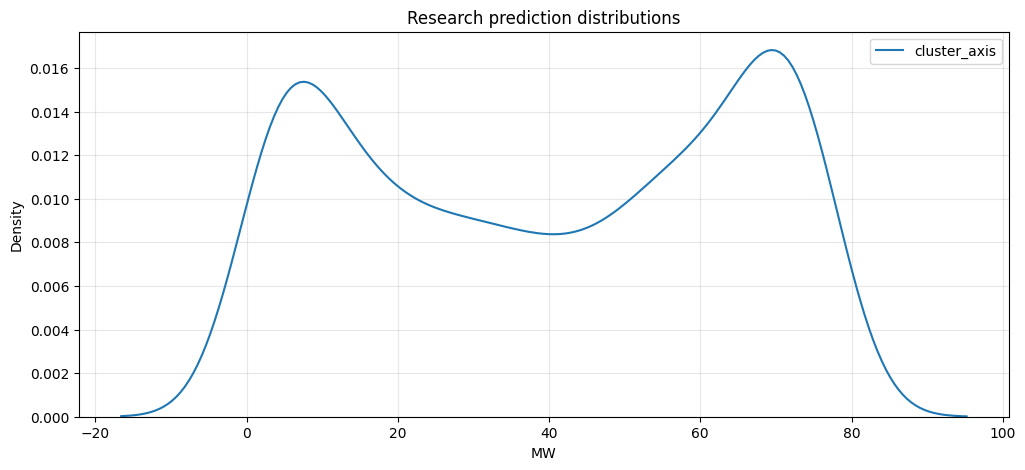

In [10]:
# ============================================================
# FINAL TRAINING: RESEARCH CANDIDATES ONLY
# safe_features submission не создаём, он есть в отдельном ноутбуке.
# ============================================================

print("=" * 90)
print("FINAL TRAINING: BEST SAFE + CLUSTER_AXIS")
print("=" * 90)

final_predictions = {}

for exp_name, blocks in research_configs.items():
    print("\n" + "=" * 90)
    print("FINAL:", exp_name)
    print("=" * 90)

    tr_research, va_research, added_cols, feature_cols = build_research_frames(blocks)

    models = fit_ensemble(
        tr_research,
        feature_cols,
        label=f"FINAL_{exp_name}",
        fast_mode=False,
    )

    pred_valid, _ = predict_ensemble(
        models,
        va_research,
        feature_cols,
    )

    submission = va_research[["row_id"]].copy()
    submission["target"] = pred_valid

    submission = (
        submission
        .sort_values("row_id")[["target"]]
        .reset_index(drop=True)
    )

    out_path = RESEARCH_SUBMISSION_PATHS[exp_name]
    submission.to_csv(out_path, index=False)

    final_predictions[exp_name] = submission["target"].to_numpy()

    print("Saved:", out_path)
    print("Shape:", submission.shape)
    display(submission.head())
    display(submission.describe())

compare_final = pd.DataFrame(final_predictions)

print("\nResearch final predictions:")
display(compare_final.describe())

plt.figure(figsize=(12, 5))
for col in compare_final.columns:
    sns.kdeplot(compare_final[col], label=col)
plt.title("Research prediction distributions")
plt.xlabel("MW")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Итоговые файлы


In [11]:
print("=" * 90)
print("FILES")
print("=" * 90)

print("Research report:")
print(RESEARCH_REPORT_PATH)
print("exists:", RESEARCH_REPORT_PATH.exists())

print("\nResearch submissions:")
for name, path in RESEARCH_SUBMISSION_PATHS.items():
    print(name, "->", path, "exists:", path.exists())

print("\nВажно:")
print("Обычный baseline здесь не обучался.")
print("safe_features используется только как baseline для local ablation.")
print("Главный файл этого ноутбука: submission_best_safe_cluster_axis_746.csv")

FILES
Research report:
outputs\pipeline_746\best_cluster_axis_vs_safe_746_report.csv
exists: True

Research submissions:
cluster_axis -> outputs\pipeline_746\submission_best_safe_cluster_axis_746.csv exists: True

Важно:
Обычный baseline здесь не обучался.
safe_features используется только как baseline для local ablation.
Главный файл этого ноутбука: submission_best_safe_cluster_axis_746.csv


## Финальная проверка главного файла


In [12]:
print("=" * 90)
print("BEST PIPELINE FILE")
print("=" * 90)

best_path = OUTPUT_DIR / "submission_best_safe_cluster_axis_746.csv"
report_path = OUTPUT_DIR / "best_cluster_axis_vs_safe_746_report.csv"

print("Best submission:")
print(best_path)
print("exists:", best_path.exists())

if best_path.exists():
    best_sub = pd.read_csv(best_path)
    print("shape:", best_sub.shape)
    display(best_sub.head())
    display(best_sub.describe())

print("\nLocal report:")
print(report_path)
print("exists:", report_path.exists())

if report_path.exists():
    report = pd.read_csv(report_path)
    display(report)

BEST PIPELINE FILE
Best submission:
outputs\pipeline_746\submission_best_safe_cluster_axis_746.csv
exists: True
shape: (2126, 1)


,target
0,6.449371
1,14.583732
2,16.513364
3,16.653180
4,13.801058


,target
count,2126.000000
mean,39.754308
std,25.616619
min,0.000000
25%,14.377538
50%,40.814571
75%,64.715851
max,78.627101



Local report:
outputs\pipeline_746\best_cluster_axis_vs_safe_746_report.csv
exists: True


,experiment,blocks,n_added_features,n_total_features,mae,delta_vs_safe
0,cluster_axis,cluster_axis,11,158,7.732054,-0.009558
1,safe_features_baseline,none,0,147,7.741612,0.000000
